# 🫁 Tuberculosis Detection using Deep Learning

This project uses a CNN-based transfer learning approach (EfficientNetB0) to classify chest X-ray images as TB positive or negative.

## 🎯 Objective
Build a robust model that generalizes well on unseen data and performs strongly on private leaderboard.

In [140]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/aahanapanwar/x-ray-data/SampleSubmission.csv
/kaggle/input/datasets/aahanapanwar/x-ray-data/Train (2).csv
/kaggle/input/datasets/aahanapanwar/x-ray-data/Test (1).csv
/kaggle/input/datasets/aahanapanwar/x-ray-data/test_small/test_small/FJQDGUND.png
/kaggle/input/datasets/aahanapanwar/x-ray-data/test_small/test_small/TMFAGLAS.png
/kaggle/input/datasets/aahanapanwar/x-ray-data/test_small/test_small/OZGPKWXR.png
/kaggle/input/datasets/aahanapanwar/x-ray-data/test_small/test_small/NQRJCNWO.png
/kaggle/input/datasets/aahanapanwar/x-ray-data/test_small/test_small/QGQBPWLJ.png
/kaggle/input/datasets/aahanapanwar/x-ray-data/test_small/test_small/XSPSFLYM.png
/kaggle/input/datasets/aahanapanwar/x-ray-data/test_small/test_small/TUSENBWD.png
/kaggle/input/datasets/aahanapanwar/x-ray-data/test_small/test_small/OUDDWOML.png
/kaggle/input/datasets/aahanapanwar/x-ray-data/test_small/test_small/KYKYIYJU.png
/kaggle/input/datasets/aahanapanwar/x-ray-data/test_small/test_small/OPSQ

In [141]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

In [142]:
train_path="/kaggle/input/datasets/aahanapanwar/x-ray-data/train_small/train_small"
test_path="/kaggle/input/datasets/aahanapanwar/x-ray-data/test_small/test_small"

In [143]:
print(len(os.listdir(train_path)))
print(len(os.listdir(test_path)))

718
82


In [144]:
print(os.listdir(train_path)[:5])

['VZJRRMAX.png', 'VUSDSHXZ.png', 'TIJQUBRR.png', 'XAVCCSSK.png', 'XLFBXAPC.png']


In [145]:
from PIL import Image
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(799.5), np.float64(789.5), np.float64(-0.5))

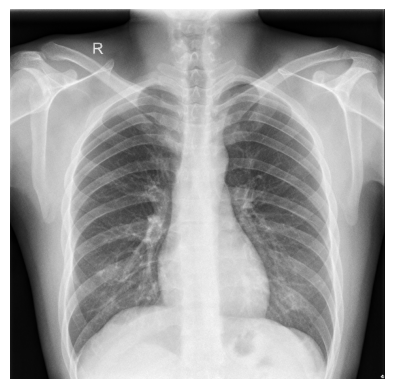

In [146]:
sample_image=os.listdir(train_path)[0]
img=Image.open(os.path.join(train_path,sample_image))
plt.imshow(img)
plt.axis("off")

## 📂 Data Loading

We load training and test metadata using CSV files and map them to image directories.

In [147]:
train_df=pd.read_csv("/kaggle/input/datasets/aahanapanwar/x-ray-data/Train (2).csv")
test_df=pd.read_csv("/kaggle/input/datasets/aahanapanwar/x-ray-data/Test (1).csv")

## ⚙️ Preprocessing

- Used `preprocess_input` (EfficientNet requirement)
- No manual rescaling

In [148]:
datagen=ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.1,)

In [149]:
train_df.head()

,filename,ID,LABEL
0,train/VTYNBFTO.png,VTYNBFTO,1
1,train/GVVXXDOZ.png,GVVXXDOZ,0
2,train/PMRSQLXN.png,PMRSQLXN,0
3,train/JXISWDUU.png,JXISWDUU,1
4,train/JVWMAACC.png,JVWMAACC,1


## 📊 Dataset

- Chest X-ray images
- Binary classification:
  - 0 → Normal
  - 1 → Tuberculosis

Dataset provided via competition platform.

In [150]:
train_df['filename'] = train_df['filename'].apply(lambda x: x.split('/')[-1])
train_df['LABEL']=train_df['LABEL'].astype(str)

## 🔄 Data Generators

To efficiently load and preprocess image data, we use Keras `ImageDataGenerator`.

### 🟢 Training Generator
- Applies preprocessing using `preprocess_input` (required for EfficientNet)

### 🔵 Validation Generator
- Uses only preprocessing (no augmentation)
- Ensures fair evaluation on unseen data

In [151]:
train_gen = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=train_path,
    x_col='filename',
    y_col='LABEL',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)




Found 647 validated image filenames belonging to 2 classes.


In [152]:
val_generator=datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=train_path,
    x_col='filename',
    y_col='LABEL',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
    
)

Found 71 validated image filenames belonging to 2 classes.


### 🧪 Initial Model (Baseline)

A simpler model was first trained with a smaller dense layer and lower dropout.

While it achieved reasonable performance, it showed weaker generalization compared to the final model.

In [160]:
base_model=EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)

)

In [161]:
base_model.trainable=False

    

In [162]:
x=base_model.output
x=layers.GlobalAveragePooling2D()(x)
x=layers.Dense(128,activation='relu')(x)

x=layers.Dropout(0.3)(x)
output=layers.Dense(1,activation='sigmoid')(x)

model_A=models.Model(inputs=base_model.input,outputs=output)



In [163]:
model_A.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='binary_crossentropy',
    metrics=['AUC']
    
    
    
)

## 🧠 Model Architecture (Final Model)

We use **EfficientNetB0** as the base model for feature extraction, leveraging pretrained weights from ImageNet.

### 🔹 Base Model
- EfficientNetB0 (pretrained)
- Top layers removed (`include_top=False`)
- Provides rich feature representations from input images

### 🔹 Custom Classification Head
- GlobalAveragePooling2D → reduces spatial dimensions
- Dense layer (256 units, ReLU activation)
- Dropout (0.4) → improves generalization and reduces overfitting
- Output layer (1 unit, sigmoid activation) for binary classification

### 🔹 Training Strategy
- Transfer learning approach


This architecture balances **model capacity and regularization**, leading to strong performance on unseen data.

In [164]:
base_model_B=EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
    
)

In [165]:
x=base_model_B.output
x=layers.GlobalAveragePooling2D()(x)
x=layers.Dense(256,activation='relu')(x)
x=layers.Dropout(0.4)(x)
output=layers.Dense(1,activation='sigmoid')(x)

model_B=models.Model(inputs=base_model_B.input,outputs=output)


In [166]:
model_B.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='binary_crossentropy',
    metrics=['AUC']
    
    
    
)

In [ ]:
model_B.fit(
    train_gen,
    validation_data=val_generator,
    epochs=20
    # callbacks=[early_stop]
    
)

In [167]:
submission=pd.read_csv("/kaggle/input/datasets/aahanapanwar/x-ray-data/SampleSubmission.csv")

In [168]:
submission.head()

,ID,LABEL
0,GTWSHFYQ,0
1,QTFSSMGD,0
2,TBLBHSYT,0
3,ZKETEOFG,0
4,GKTPBGZP,0


In [ ]:
test_df['filename'] = test_df['filename'].apply(lambda x: x.split('/')[-1])

## 🔁 Test Time Augmentation (TTA)

To improve prediction stability and generalization, we apply **Test Time Augmentation (TTA)** during inference.

Instead of making a single prediction per image, multiple augmented versions of each test image are evaluated, and their predictions are averaged.

### 🔹 Approach
- Original image + horizontally flipped version
- Predictions are averaged to produce the final output

### 🔹 Why TTA?
- Reduces prediction variance  
- Improves robustness  
- Enhances performance on unseen data  

---

## 📈 Impact on Performance

Applying TTA resulted in a measurable improvement in leaderboard performance:

- Without TTA:  
  - Private AUC ≈ **0.95**

- With TTA (horizontal flip):  
  - Public AUC ≈ **0.959**  
  - Private AUC ≈ **0.9628**

This demonstrates that TTA improves both **stability and generalization** of the model.

In [ ]:
tta_datagen=ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True
    
    )

In [ ]:
tta_steps=5
tta_preds_B=[]

for i in range(tta_steps):
    tta_generator=tta_datagen.flow_from_dataframe(
        dataframe=test_df,
        directory=test_path,
        x_col='filename',
        y_col=None,
        target_size=(224,224),
        batch_size=32,
        class_mode=None,
        shuffle=False)
    preds=model_B.predict(tta_generator,verbose=1)
    tta_preds_B.append(preds)

In [169]:
tta_preds_B = np.mean(tta_preds_B, axis=0)

In [ ]:
submission['LABEL']=tta_preds_B.flatten()

In [ ]:
submission.to_csv('submission_csv',index=False)

In [ ]:
submission.head()